# Notebook 1 — Basic Exploratory Data Analysis: SECOM

**Dataset:** SECOM, 1567 wafers × 590 sensor features + binary target
(104 fails, 6.6%) + measurement timestamp. Loaded live from SQLite via
`extract()`; the database is the single source of truth.

**Note on raw vs. preprocessed features:** the pre-processing pipeline drops
constant and >50%-NaN features for *value-based* analysis (~257 survive).
Missingness analysis (Section 3) deliberately runs on the raw 590 features,
because high-NaN features are exactly where dropout structure lives — their
values are unusable, but their dropout patterns are analyzed and turned into
indicator features.

**Goal:** understand distributions, missingness structure, feature
relationships, and class imbalance before modeling.

---

> **Naming note (2026-09-01, post-migration).** This notebook now reads the live
> database (`data/secom.db` via `extract()`); the analysis was written with legacy
> 0-based integer column names, so the loading cell contains a marked shim mapping
> s-names back (legacy `n` = `s(n+1)` minus one). New analysis should use s-names
> directly — `data/column_registry.csv` is the reference for names, roles, and
> active/excluded status.


## 1. Setup & Imports

We load all required libraries, configure plot aesthetics, detect column names and types, and ingest the **train** data.

**Key loading decisions:**
- Loaded live from SQLite via extract() (legacy-view shim in the loader). 
- The imported dataframe is the single source of truth.
- All features are float 
- Target is int and has a datetime timestamp.


In [ ]:
import logging
import os
import sys

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

print(os.getcwd())




def setup_logging(level: int = logging.INFO, log_file: str | None = "eda.log") -> logging.Logger:
    """Idempotent logger for notebook use: console + optional file."""
    logger = logging.getLogger("secom")
    logger.setLevel(level)

    if logger.handlers:  # avoid duplicate handlers on cell re-runs
        return logger

    fmt = logging.Formatter(
        "%(asctime)s | %(levelname)-7s | %(name)s | %(message)s",
        datefmt="%Y-%m-%d %H:%M:%S",
    )

    ch = logging.StreamHandler(sys.stdout)  # stdout, not stderr, shows cleanly in Jupyter
    ch.setFormatter(fmt)
    logger.addHandler(ch)

    if log_file:
        fh = logging.FileHandler(log_file, mode="a", encoding="utf-8")
        fh.setFormatter(fmt)
        logger.addHandler(fh)

    logger.propagate = False  # don't double-print via root logger
    return logger


log = setup_logging()
log.info("Logging initialised")

/home/python_user/coding/ds/semcon/notebooks
2026-09-01 20:13:15 | INFO    | secom | Logging initialised


In [2]:
# ── Data loading: live from the DB, presented in the legacy view ──────────
# Post-migration (2026-09-01): the source of truth is data/secom.db via
# extract(). The analysis below was written with legacy 0-based integer
# column names, so this marked shim maps s-names back (legacy n = s(n+1)).
# New analysis should use s-names directly; data/column_registry.csv is the
# reference. The frozen parquets remain as historical artifacts only.

from semcon import schema
from semcon.db import feature_columns, get_engine, load_registry
from semcon.extract import extract
from semcon.paths import ARTIFACTS


def load_data():
    """Wide frame from SQLite -> legacy layout:
    df_train = 590 sensors with 0-based integer names, raw file order;
    dfy = target (0/1, recoded from raw -1/1) + timestamp."""
    engine = get_engine()
    df = extract(engine).sort_values(schema.KEY_COL).reset_index(drop=True)

    sensors = [c for c in df.columns if c.startswith(schema.SENSOR_PREFIX) and len(c) == 4]
    df_train = df[sensors].copy()
    df_train.columns = [int(c[1:]) - 1 for c in sensors]  # legacy 0-based

    dfy = pd.DataFrame(
        {
            "target": df[schema.TARGET_COL].eq(1).astype("int8"),
            "timestamp": df[schema.TIME_COL],
        }
    )

    assert df_train.shape == (1567, 590), "Train has the wrong shape"
    assert len(df_train) == len(dfy), "Feature/target row mismatch"
    log.info(f"[eda] from SQLite: features {df_train.shape}, target {dfy.shape}")
    return df_train, dfy, engine


df_train, dfy, engine = load_data()

nums = df_train.select_dtypes(include=["float"]).columns.tolist()
assert df_train.shape[1] == len(nums), "nums are missing some df_train features"

2026-09-01 20:13:17 | INFO    | secom | [eda] from SQLite: features (1567, 590), target (1567, 2)


In [3]:
display(df_train)

,0,1,2,3,4,5,6,7,8,9,...,580,581,582,583,584,585,586,587,588,589
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,0.0162,...,NaN,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN
1,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,-0.0005,...,0.0060,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045
2,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,0.0041,...,0.0148,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602
3,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,-0.0124,...,0.0044,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432
4,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,-0.0031,...,NaN,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1562,2899.41,2464.36,2179.7333,3085.3781,1.4843,100.0,82.2467,0.1248,1.3424,-0.0045,...,0.0047,203.1720,0.4988,0.0143,0.0039,2.8669,0.0068,0.0138,0.0047,203.1720
1563,3052.31,2522.55,2198.5667,1124.6595,0.8763,100.0,98.4689,0.1205,1.4333,-0.0061,...,NaN,NaN,0.4975,0.0131,0.0036,2.6238,0.0068,0.0138,0.0047,203.1720
1564,2978.81,2379.78,2206.3000,1110.4967,0.8236,100.0,99.4122,0.1208,NaN,NaN,...,0.0025,43.5231,0.4987,0.0153,0.0041,3.0590,0.0197,0.0086,0.0025,43.5231
1565,2894.92,2532.01,2177.0333,1183.7287,1.5726,100.0,98.7978,0.1213,1.4622,-0.0072,...,0.0075,93.4941,0.5004,0.0178,0.0038,3.5662,0.0262,0.0245,0.0075,93.4941


In [4]:
# Data types
print("=== Column dtypes ===")
print(f" All features are float. Number of features {len(nums)}")
dfy.dtypes.to_frame("dtype")

=== Column dtypes ===
 All features are float. Number of features 590


,dtype
target,int8
timestamp,datetime64[us]


        count  proportion_%  ratio_to_smallest
target                                        
0        1463         93.36              14.07
1         104          6.64               1.00


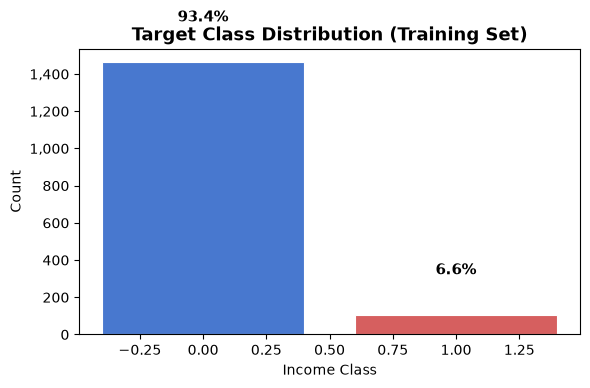

In [ ]:
# Target value counts + bar chart with percentage annotations
vc = dfy["target"].value_counts()
pct = dfy["target"].value_counts(normalize=True) * 100
# Overall proportions for target
vc_sorted = vc.sort_index()

prop = (vc_sorted / vc_sorted.sum() * 100).round(2)

baseline = vc_sorted.min()
ratio = (vc_sorted / baseline).round(2)

summary = pd.DataFrame(
    {
        "count": vc_sorted,
        "proportion_%": prop,
        "ratio_to_smallest": ratio,
    }
)

print(summary)

# Plot class counts
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(
    vc.index, vc.values, color=["#4878CF", "#D65F5F", "#48CF71"], edgecolor="white", linewidth=0.8
)

for bar, p in zip(bars, pct.values, strict=True):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 200,
        f"{p:.1f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
    )
ax.set_title("Target Class Distribution (Training Set)", fontsize=13, fontweight="bold")
ax.set_xlabel("Income Class")
ax.set_ylabel("Count")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

## 3. Missing Value Analysis

SECOM contains substantial missing data: sensors record `NaN` both sporadically and in
large structured blocks. This is a semiconductor process-surveillance dataset, so
missingness is expected to be driven by sensor dropouts and measurement-protocol
differences rather than random noise — i.e. closer to MNAR than MCAR.

**Why this matters for modeling:**
- If missingness correlates with the target, it is a signal channel in its own right.
- Structured (block-wise) missingness can confound time and target effects.
- Imputation choices depend on the mechanism; gradient-boosted trees can route NaNs
  natively, which lets us defer imputation entirely for the first baseline.

**Plan:** (1) marginal missing rates, (2) missing rate by class, (3) co-missingness
structure → dropout cliques, (4) clique-level association with the target,
(5) block/time structure, (6) row-level quality.

### 3.1 Marginal missing rates

Per-feature missing counts. The top of the table is dominated by feature groups with
*identical* counts — the first hint that missingness is structured, not independent:
- {157, 158, 292, 293}: 1429/1567 missing (91.2%) — measured on only ~138 wafers
- {85, 220, 358, 492}: 1341 (85.6%)
- {516, 517, ...}: 1018 (65.0%)

Note: the >50% drop rule used in the pre-processing pipeline removed exactly these
features. They are unusable as continuous inputs, but their dropout pattern may still
carry information, which is why this analysis runs on the raw 590 features.

In [6]:
# Missing value counts
missing = df_train.isnull().sum()
missing_pct = (df_train.isnull().sum() / len(df_train) * 100).round(2)
missing_df = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_df = missing_df[missing_df["missing_count"] > 0].sort_values(
    "missing_count", ascending=False
)

display(missing_df.head(10))

,missing_count,missing_pct
292,1429,91.19
157,1429,91.19
158,1429,91.19
293,1429,91.19
492,1341,85.58
220,1341,85.58
358,1341,85.58
85,1341,85.58
516,1018,64.96
517,1018,64.96


**Summary:** ~35 feature groups contain all the missing data; the worst are >85% NaN.
Identical counts across features indicate shared dropout events — quantified next.

### 3.2 Missing rate by class

A dropout that coincides with failures is a potential fault symptom. We compare the
per-feature missing rate between pass and fail wafers. Because the classes are
imbalanced (104 fails / 1463 passes), absolute gaps — not ratios — are the stable
quantity here.

In [7]:
# %% missingness by class
y = dfy["target"].astype(bool)

miss_by_class = pd.DataFrame(
    {
        "miss_pass": df_train[~y].isna().mean(),
        "miss_fail": df_train[y].isna().mean(),
    }
)
miss_by_class["gap"] = (miss_by_class["miss_fail"] - miss_by_class["miss_pass"]).abs()
miss_by_class = miss_by_class.sort_values("gap", ascending=False)

display(miss_by_class.head(30))
log.info(f"Features with class missing-gap > 5pp: {(miss_by_class['gap'] > 0.05).sum()}")

,miss_pass,miss_fail,gap
72,0.518113,0.346154,0.171960
73,0.518113,0.346154,0.171960
345,0.518113,0.346154,0.171960
346,0.518113,0.346154,0.171960
385,0.466165,0.317308,0.148858
112,0.466165,0.317308,0.148858
519,0.466165,0.317308,0.148858
247,0.466165,0.317308,0.148858
111,0.645249,0.711538,0.066289
109,0.645249,0.711538,0.066289


2026-09-01 20:13:17 | INFO    | secom | Features with class missing-gap > 5pp: 28


**Summary:** 28 features show a class gap > 5pp, again in identical-value groups.
Notably the direction is *negative*: the largest groups are missing **less** often on
fails (e.g. 46.6% on passes vs 31.7% on fails). Missingness here does not look like
sensor-death-during-failure; it looks like a measurement-protocol difference.
Statistical confirmation comes from the clique-level Fisher tests in 3.4.

### 3.3 Dropout cliques (connected components)

We correlate the binary is-missing vectors across features (Pearson r on binary data =
phi coefficient). Two non-constant indicators have r = 1.0 **iff they are missing on
exactly the same wafers**. We then take connected components of the r ≈ 1 graph, which
collapses each set of identically-dropping features into one *dropout clique*.

(A flat list of top pairs would enumerate each k-member clique k(k-1)/2 times —
connected components are the honest summary.)

In [8]:
# %% collapse perfect co-missing pairs into dropout groups
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components

# %% co-missingness clustermap
miss_ind = df_train.isna().astype("int8")
co_miss = miss_ind.corr()

adj = (co_miss >= 0.999).astype("int8").to_numpy(copy=True)  # adjacency: r≈1 => same dropout event
np.fill_diagonal(adj, 0)

n_groups, labels = connected_components(csr_matrix(adj), directed=False)
groups = pd.Series(labels, index=co_miss.index)

# for g, members in groups.groupby(groups):
#     if len(members) > 1:
#         print(f"group {g}: {list(members.index)}")

# %% save dropout groups with stats
dropout_groups = groups.groupby(groups).apply(lambda s: list(s.index))
dropout_groups = dropout_groups[dropout_groups.str.len() > 1]

dropout_summary = pd.DataFrame(
    {
        "members": dropout_groups,
        "size": dropout_groups.str.len(),
        "n_missing": [int(df_train[m].isna().any(axis=1).sum()) for m in dropout_groups],
    }
)
dropout_summary["missing_pct"] = (dropout_summary["n_missing"] / len(df_train) * 100).round(2)
dropout_summary = dropout_summary.sort_values("n_missing", ascending=False)

display(dropout_summary)
log.info(
    f"{len(dropout_groups)} dropout cliques saved, "
    f"{dropout_summary['size'].sum()} features involved"
)

,members,size,n_missing,missing_pct
39,"[157, 158, 292, 293]",4,1429,91.19
19,"[85, 220, 358, 492]",4,1341,85.58
26,"[109, 110, 111, 244, 245, 246, 382, 383, 384, ...",12,1018,64.96
84,"[578, 579, 580, 581]",4,949,60.56
15,"[72, 73, 345, 346]",4,794,50.67
27,"[112, 247, 385, 519]",4,715,45.63
75,"[562, 563, 564, 565, 566, 567, 568, 569]",8,273,17.42
73,"[546, 547, 548, 549, 550, 551, 552, 553, 554, ...",12,260,16.59
23,"[89, 90, 224, 225, 362, 363, 496, 497]",8,51,3.25
16,"[75, 76, 77, 78, 79, 80, 81, 82, 118, 210, 211...",36,24,1.53


2026-09-01 20:13:19 | INFO    | secom | 35 dropout cliques saved, 538 features involved


**Summary:** 35 multi-feature cliques cover 538 of 590 features. Two structural facts:
1. **Cliques are contiguous column runs** (dominant within-clique offset = 1) —
   adjacent channels drop together, consistent with channels on a shared sensor array.
2. **The same dropout recurs at offsets of ~135–138 columns** — the 590 columns are a
   repeated layout of ~135 channels, 4 full repeats plus a partial 5th block
   (boundaries: 0 / 136 / 271 / 409 / 542). This is strong evidence the features are
   the same sensor suite recorded at ~4–5 points in the process chain.

Cliques spanning all blocks at one channel (e.g. {85, 220, 358, 492}) indicate a
channel-level measurement issue across the whole line; block-local cliques are
step-specific dropouts.

### 3.4 Clique × target association (Fisher exact test)

One test per clique: does missingness of the clique shift the fail rate?
Fisher's exact test is appropriate given only 104 positives. Small cliques
(n_missing < ~20) have no power — their p-values are uninformative regardless of
direction, so interpretation focuses on the large cliques.

In [ ]:
# %% clique-level target association
from scipy.stats import fisher_exact

rows = []
for _label, members in dropout_groups.items():
    clique_missing = df_train[members].isna().any(axis=1)
    tab = pd.crosstab(clique_missing, y)
    odds, p = fisher_exact(tab)
    rows.append(
        {
            "clique": members,
            "n_missing": int(clique_missing.sum()),
            "fail_rate_present": y[~clique_missing].mean(),
            "fail_rate_missing": y[clique_missing].mean(),
            "odds_ratio": odds,
            "fisher_p": round(p, 4),
        }
    )

clique_target = pd.DataFrame(rows).sort_values("fisher_p")
display(clique_target.head(10))

,clique,n_missing,fail_rate_present,fail_rate_missing,odds_ratio,fisher_p
14,"[72, 73, 345, 346]",794,0.087969,0.045340,0.492395,0.0008
23,"[112, 247, 385, 519]",715,0.083333,0.046154,0.532258,0.0031
7,"[21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 1...",2,0.065815,0.500000,14.194175,0.1284
31,"[562, 563, 564, 565, 566, 567, 568, 569]",273,0.061824,0.087912,1.462651,0.1397
22,"[109, 110, 111, 244, 245, 246, 382, 383, 384, ...",1018,0.054645,0.072692,1.356144,0.2017
11,"[53, 54, 55, 56, 57, 58, 190, 191, 192, 193, 1...",4,0.065899,0.250000,4.724919,0.2404
19,"[89, 90, 224, 225, 362, 363, 496, 497]",51,0.067942,0.019608,0.274369,0.2520
18,"[85, 220, 358, 492]",1341,0.048673,0.069351,1.456512,0.3114
1,"[1, 137, 272, 410]",7,0.066026,0.142857,2.357605,0.3823
9,"[40, 41, 178, 313, 314, 449, 450]",24,0.067401,0.000000,0.000000,0.4000


**Summary:** Two cliques carry statistically supported association:

| clique | n_missing | fail rate present | fail rate missing | odds ratio | p |
|---|---|---|---|---|---|
| {72, 73, 345, 346} | 794 | 8.8% | 4.5% | 0.49 | 0.0008 |
| {112, 247, 385, 519} | 715 | 8.3% | 4.6% | 0.53 | 0.0031 |

Wafers **missing** these measurements fail at roughly **half** the rate of wafers that
have them. The most plausible mechanisms are (a) suspicion-triggered extra screening
(measured wafers were pre-selected as risky) or (b) product/routing differences
(different wafers skip different stations and have different base yields). Both are
legitimate, observable-at-prediction-time signal — not label leakage. The
early-scrap hypothesis (fails missing *late* measurements because they were pulled
from the line) would predict the opposite direction and is rejected by the block-level
plot in 3.5, with a minor exception in block 5.

**Decision:** construct one missing indicator per significant clique (`miss_clq14`,
`miss_clq23`) for the modeling feature set. Clique selection here used the labels, so
these indicators must re-validate in cross-validation; no other cliques are turned
into features.

### 3.5 Missingness by block, class, and time

Using the recovered layout (~135 channels × 4 full blocks + partial 5th), we check
where in the process chain missingness lives, and when in time it occurs.

In [ ]:
# %% clique offset structure
offsets = [b - a for m in dropout_groups for a, b in zip(sorted(m), sorted(m)[1:], strict=True)]
pd.Series(offsets).value_counts().head(10)

1      398
135     11
3       10
138      9
134      8
4        8
131      7
136      6
132      5
133      4
Name: count, dtype: int64

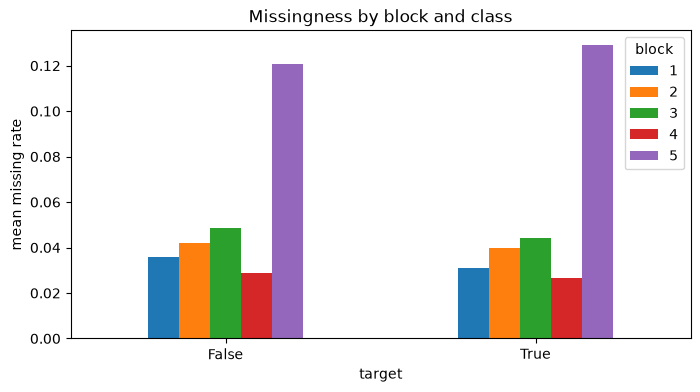

In [11]:
# %% block / channel mapping
bounds = [0, 136, 271, 409, 542, 590]
feat_map = pd.DataFrame({"feature": range(590)})
feat_map["block"] = pd.cut(feat_map["feature"], bins=bounds, right=False, labels=False) + 1
feat_map["channel"] = feat_map["feature"] - feat_map.groupby("block")["feature"].transform("min")

# %% missingness by block, fails vs passes — early-scrap test
block_of = feat_map.set_index("feature")["block"]
miss_block = df_train.isna().T.groupby(block_of).mean().T  # wafer x block missing rate
miss_block.groupby(y).mean().plot.bar(
    rot=0, figsize=(8, 4), ylabel="mean missing rate", title="Missingness by block and class"
)
plt.show()

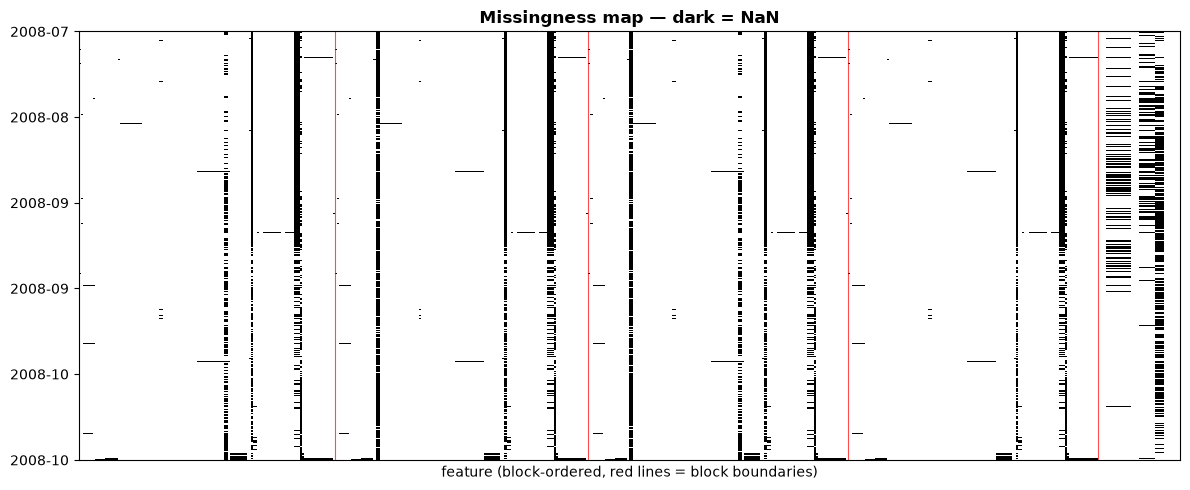

In [12]:
# %% missingness map — columns ordered by block/channel, rows by time
order = feat_map.sort_values(["block", "channel"])["feature"].tolist()
nan_cols = [c for c in order if df_train[c].isna().any()]  # only columns that can show anything

miss_map = df_train[nan_cols].isna().astype("int8").set_index(dfy["timestamp"]).sort_index()

fig, ax = plt.subplots(figsize=(12, 5))
ax.imshow(miss_map.values, aspect="auto", cmap="Greys", interpolation="nearest", origin="upper")

# block boundary lines + date ticks for orientation
bounds_in_plot = [
    i
    for i, c in enumerate(nan_cols)
    if i > 0
    and feat_map.set_index("feature").loc[c, "block"]
    != feat_map.set_index("feature").loc[nan_cols[i - 1], "block"]
]
for b in bounds_in_plot:
    ax.axvline(b - 0.5, color="red", lw=0.8, alpha=0.7)

yticks = np.linspace(0, len(miss_map) - 1, 6, dtype=int)
ax.set_yticks(yticks)
ax.set_yticklabels([miss_map.index[i].strftime("%Y-%m") for i in yticks])
ax.set_xticks([])
ax.set_xlabel("feature (block-ordered, red lines = block boundaries)")
ax.set_title("Missingness map — dark = NaN", fontweight="bold")
plt.tight_layout()
plt.show()

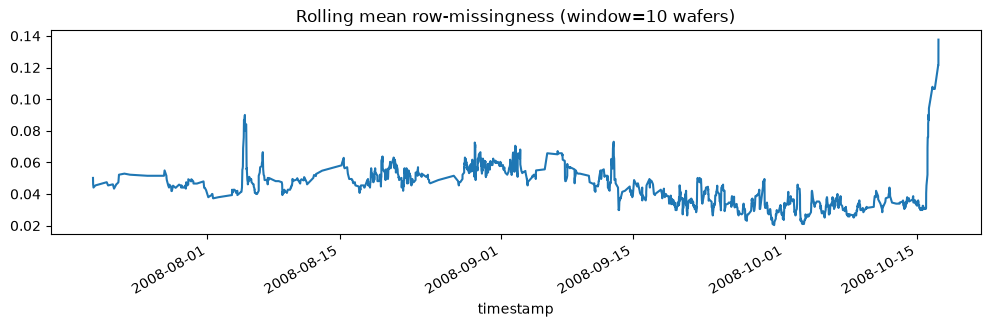

In [13]:
# %% missingness vs time
tmp = dfy[["timestamp"]].copy()
tmp["row_miss"] = df_train.isna().mean(axis=1).values
tmp = tmp.set_index("timestamp").sort_index()
tmp["row_miss"].rolling(10, min_periods=10).mean().plot(
    figsize=(12, 3), title="Rolling mean row-missingness (window=10 wafers)"
)
plt.show()

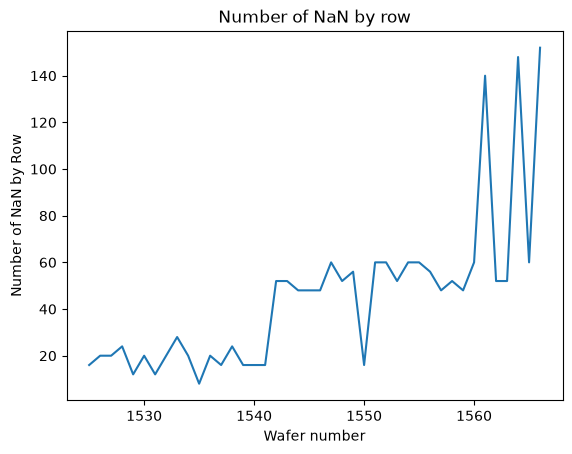

In [14]:
# Explore at which point the nans explode.
df_temp = df_train.isna().sum(axis=1).to_frame(name="NaN_Count")  # Sum all nans by row
df_temp = pd.concat([df_temp, dfy], axis=1).sort_values("timestamp").reset_index(drop=True)

df_temp.loc[1525:, "NaN_Count"].plot(kind="line", title="Number of NaN by row")
plt.xlabel("Wafer number")
plt.ylabel("Number of NaN by Row")
plt.show()

In [15]:
# %% tail vs rest: fail rate and clique drivers
N_TAIL = 27  # adjust after seeing where the surge starts

order_time = dfy["timestamp"].sort_values().index  # robust to any row shuffling
tail_idx = order_time[-N_TAIL:]
is_tail = dfy.index.isin(tail_idx)

print(
    f"fail rate  tail: {dfy.loc[is_tail, 'target'].mean():.3f} "
    f"({int(dfy.loc[is_tail, 'target'].sum())}/{is_tail.sum()})"
)
print(
    f"fail rate  rest: {dfy.loc[~is_tail, 'target'].mean():.3f} "
    f"({int(dfy.loc[~is_tail, 'target'].sum())}/{(~is_tail).sum()})"
)

# which cliques drive the surge: missing rate in tail vs rest, biggest contributors first
clique_tail = pd.DataFrame(
    {
        "clique": dropout_groups,
        "n_missing": [int(df_train[m].isna().any(axis=1).sum()) for m in dropout_groups],
        "miss_tail": [df_train[m].isna().any(axis=1)[is_tail].mean() for m in dropout_groups],
        "miss_rest": [df_train[m].isna().any(axis=1)[~is_tail].mean() for m in dropout_groups],
    }
)
clique_tail["surge"] = clique_tail["miss_tail"] - clique_tail["miss_rest"]
display(clique_tail.sort_values("surge", ascending=False).head(8))
log.info(
    f"Tail check: fail rate tail={dfy.loc[is_tail, 'target'].mean():.3f} "
    f"rest={dfy.loc[~is_tail, 'target'].mean():.3f}"
)

fail rate  tail: 0.000 (0/27)
fail rate  rest: 0.068 (104/1540)


,clique,n_missing,miss_tail,miss_rest,surge
16,"[75, 76, 77, 78, 79, 80, 81, 82, 118, 210, 211...",24,0.888889,0.000000,0.888889
27,"[112, 247, 385, 519]",715,1.000000,0.446753,0.553247
15,"[72, 73, 345, 346]",794,0.925926,0.499351,0.426575
23,"[89, 90, 224, 225, 362, 363, 496, 497]",51,0.296296,0.027922,0.268374
5,"[13, 14, 15, 16, 17, 18, 149, 150, 151, 152, 1...",3,0.111111,0.000000,0.111111
36,"[132, 133, 134, 267, 268, 269, 405, 406, 407, ...",8,0.111111,0.003247,0.107864
35,"[121, 122, 123, 124, 125, 126, 127, 128, 129, ...",9,0.111111,0.003896,0.107215
4,"[8, 9, 10, 11, 12, 144, 145, 146, 147, 148, 27...",2,0.074074,0.000000,0.074074


2026-09-01 20:13:22 | INFO    | secom | Tail check: fail rate tail=0.000 rest=0.068


**Summary:**
- Blocks 1–4: passes have slightly *more* missingness than fails (consistent with the
  clique-level result). Block 5 is the exception — fails edge ahead — and it is the
  final station group. Weak effect; flagged, not concluded.
- Time: row-missingness is flat (~constant per wafer) for the whole run, then jumps
  discretely over the final ~27 wafers. A regime change, not drift.

**Tail check (fail rate tail vs rest): 0.0% (0/27) vs 6.8% (104/1540).** The tail is
~100% missing the two target-associated cliques from 3.4, so its zero fails are
*directionally consistent with the clique association* — time and clique effects
cannot be separated at n = 27 (P(0 fails | 27 random wafers) ≈ 0.15 under the base
rate). Read: the tail regime looks benign, but the evidence is entangled, not
independent.

**Consequences for modeling:** (1) a time-blocked holdout (last ~15–20% by timestamp)
remains the robustness check — the tail has a different sensor regime; (2) when
scoring that holdout, note its fail count is likely ~0, so PR-AUC there is
uninformative — interpret holdout metrics on precision/recall at fixed threshold, or
choose the holdout boundary just *before* the explosion.

### 3.6 Row-level (per-wafer) missingness

Per-wafer missing rate: mean 4.5%, median 4.1%, max 25.8%. No wafer comes close to
being unrecoverable (worst case has >74% of channels present), so **no rows are
dropped**. Class means are nearly identical (pass 4.55% vs fail 4.32%): at the
whole-row level, missingness is not a fail symptom.

In [16]:
# %% row-level missing
row_miss = df_train.isna().mean(axis=1)
print(row_miss.describe())
print(f"Rows missing >50% of features: {(row_miss > 0.5).sum()}")
print(f"Row missing rate by class:\n{row_miss.groupby(y).describe()}")

count    1567.000000
mean        0.045375
std         0.022674
min         0.006780
25%         0.033898
50%         0.040678
75%         0.054237
max         0.257627
dtype: float64
Rows missing >50% of features: 0
Row missing rate by class:
         count      mean       std       min       25%       50%       75%  \
target                                                                       
False   1463.0  0.045533  0.023034  0.006780  0.033898  0.040678  0.054237   
True     104.0  0.043155  0.016742  0.013559  0.033898  0.040678  0.047458   

             max  
target            
False   0.257627  
True    0.108475  


**Summary:** All 1,567 rows retained. A per-row `row_missing_rate` column is a
candidate data-quality feature but is expected to be weak; defer to fold-internal
feature selection rather than forcing it in.

### 3.7 Missing-value analysis — conclusions

1. **Structure recovered.** Missingness is fully explained by 35 dropout cliques over
   a repeated ~135-channel × ~4.5-block column layout. Cliques are adjacent-channel
   groups; cross-block cliques mark the same channel dropping at every process step.
2. **Signal found.** Two cliques halve the fail rate when missing (OR ≈ 0.5,
   p ≤ 0.003). Direction implies measurement-protocol/routing information, not sensor
   degradation. Two indicator features (`miss_clq14`, `miss_clq23`) are added to the
   modeling set; all other cliques are documented but not featurized.
3. **No leakage indicators**, with one open flag: block 5 shows a weak fail-elevated
   missingness, to be re-examined on the time-blocked holdout.
4. **No rows or (further) columns dropped** here. High-NaN features (>50%) stay out of
   the value feature set as decided in pre-processing, but their dropout patterns are
   captured by the indicators above.
5. **Imputation deferred.** First baseline (LightGBM/XGBoost) uses native NaN routing;
   any imputation strategy is a later, model-specific decision.

   ---

## 4. Numeric Feature Distributions

There are no categorical features, so this section covers the full feature set: the
257 continuous sensors surviving pre-processing. With 257 features, plot-per-feature
EDA is not feasible — the analysis is **table-driven**: per-feature statistics with
flag columns, extreme-slice displays, and targeted plots only for top-ranked
candidates.

**Plan:** (1) marginal summary statistics, (2) distribution-shape triage (flags),
(3) class-conditional separation ranking (Hedges' g + Mann–Whitney, FDR-corrected),
(4) targeted plots + tail-enrichment check, (5) variance-shift analysis,
(6) mutual information as a corroborating signal, (7) master feature table.

**Leakage note:** all rankings in this section are computed on the full dataset and
are exploratory. Operative feature selection happens inside cross-validation folds;
nothing here is a final selection decision.

In [17]:
# Active feature set, registry-filtered — the legacy dfX_v1 view.
# The registry answers "which columns are active"; names map back to legacy.
active = [c for c in feature_columns(load_registry(engine)) if c.startswith(schema.SENSOR_PREFIX)]
legacy_active = [int(c[1:]) - 1 for c in active]
df_train = df_train[legacy_active]
log.info(f"[eda] active feature set from registry: {df_train.shape}")

nums = df_train.select_dtypes(include=["float"]).columns.tolist()
assert df_train.shape[1] == len(nums), "nums are missing some df_train features"

2026-09-01 20:13:22 | INFO    | secom | [eda] active feature set from registry: (1567, 257)


### 4.1 Marginal summary statistics

One row per feature: mean, median, std, skew, kurtosis, min, max, pct_zeros, n_unique,
joined with the pre-processing diagnostics (dom_frac, cv, missing_rate, deviant
enrichment). The full table is an artifact, not a display — we show extreme slices
(top/bottom 10 by skew, kurtosis, cv, missing rate).

In [18]:
def build_univariate_summary(df: pd.DataFrame, numeric_cols: list) -> pd.DataFrame:
    """
    Build a comprehensive univariate statistics summary table.

    Parameters
    ----------
    df : pd.DataFrame
    numeric_cols : list of str

    Returns
    -------
    pd.DataFrame
        Summary statistics indexed by column name.
    """
    rows = []
    for col in numeric_cols:
        s = df[col].dropna()
        rows.append(
            {
                "mean": round(s.mean(), 3),
                "median": round(s.median(), 3),
                "std": round(s.std(), 3),
                "skew": round(s.skew(), 3),
                "kurtosis": round(s.kurt(), 3),
                "min": s.min(),
                "max": s.max(),
                "pct_zeros": round((s == 0).sum() / len(s) * 100, 2),
            }
        )
    return pd.DataFrame(rows, index=numeric_cols)


summary_table = build_univariate_summary(df_train, nums)

# Diagnostics written by explore.py — locate robustly (repo-rooted path,
# dated-folder or legacy flat layout), and map the s-name index to legacy.
_candidates = sorted(ARTIFACTS.glob("eda_*/diagnostic.parquet"))
_candidates.append(ARTIFACTS / "diagnostic.parquet")  # legacy flat fallback
_diag = next((p for p in _candidates if p.exists()), None)
assert _diag is not None, (
    f"No diagnostic.parquet under {ARTIFACTS} — rerun explore.py to regenerate"
)

df_diagnostic = pd.read_parquet(_diag)
df_diagnostic.index = [
    int(c[1:]) - 1
    if isinstance(c, str) and c.startswith(schema.SENSOR_PREFIX) and len(c) == 4
    else c
    for c in df_diagnostic.index
]
print(f"diagnostics: {_diag.name} | {df_diagnostic.shape}")
# Join on the index and filter (inner join keeps only shared keys)
df_eda_diag = summary_table.join(df_diagnostic, how="inner")

display(df_eda_diag)

diagnostics: diagnostic.parquet | (590, 8)


,mean,median,std,skew,kurtosis,min,max,pct_zeros,n_unique,dom_frac,cv,missing_rate,n_deviant,dev_fail_rate,enrichment,verdict
0,3014.453,3011.490,73.622,0.514,1.471,2743.2400,3356.3500,0.00,1520,0.001281,0.024423,0.003829,1559,0.066709,1.005131,keep
1,2495.850,2499.405,80.408,-0.043,2.241,2158.7500,2846.4400,0.00,1504,0.001923,0.032217,0.004467,1557,0.065511,0.987068,keep
2,2200.547,2201.067,29.513,-0.306,2.305,2060.6600,2315.2667,0.00,507,0.007727,0.013412,0.008934,1541,0.066840,1.007095,keep
3,1396.377,1285.214,441.692,1.712,4.595,0.0000,3715.0417,0.06,518,0.006439,0.316313,0.008934,1543,0.066753,1.005789,keep
6,101.113,101.512,6.237,-0.107,2.019,82.1311,129.2522,0.00,510,0.006439,0.061686,0.008934,1543,0.066753,1.005789,keep
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
577,16.642,13.818,12.485,4.170,19.458,4.5820,96.9601,0.00,851,0.010211,0.750210,0.000000,1551,0.067054,1.010316,keep
585,3.068,2.758,3.578,24.697,659.562,1.1975,99.3032,0.00,1502,0.001916,1.166309,0.000638,1563,0.065899,0.992919,keep
586,0.021,0.020,0.012,1.438,6.976,-0.0169,0.1028,0.00,322,0.017880,0.575912,0.000638,1538,0.067620,1.018856,keep
588,0.005,0.005,0.003,2.029,8.239,0.0010,0.0286,0.00,120,0.030651,0.542663,0.000638,1518,0.067852,1.022354,keep


**Summary:** sensor scales span ~5 orders of magnitude (from ~0.005 to ~3000), so all
spread comparisons use relative measures (cv, standardized effect sizes). The
kurtosis leaders (kurtosis in the hundreds) are features whose statistics are driven
by a handful of extreme rows — they are flagged for the outlier check in 4.4 before
any separation statistic is trusted.

### 4.2 Distribution-shape flags

Flags per feature: |skew| > 1, kurtosis > 2 (heavy tail), kurtosis > 10
(outlier-dominated), zeros > 1%, missing > 5%, dominant value > 95%. A separate check
asks whether skew survives clipping the extreme 1% — if not, the skew is
outlier-driven and winsorizing (not log-transform) is the right treatment later.

**Scope note:** shape corrections are inert for the GBDT baseline (trees are
rank-based). The transformation watchlist (log if min ≥ 0, else Yeo–Johnson) is
recorded for the logistic-regression / NN models, not applied now.

In [19]:
# %% display extreme slices of the feature table
def show_extremes(
    feat_df: pd.DataFrame, col: str, n: int = 10, cols: list | None = None, ascending: bool = False
) -> pd.DataFrame:
    """Top/bottom-n features by a stat, with a compact column set."""
    cols = cols or ["mean", "std", "skew", "kurtosis", "missing_rate", "enrichment"]
    return feat_df.sort_values(col, ascending=ascending).head(n)[cols]


# the views that matter for shape triage
print("Table sorted on skew")
display(show_extremes(df_eda_diag, "skew"))  # right-skew leaders
print("Table sorted on kurtosis")
display(show_extremes(df_eda_diag, "kurtosis"))  # heavy-tail / outlier leaders
print("Table sorted on cv")
display(show_extremes(df_eda_diag, "cv"))  # highest relative spread
print("Table sorted on missing_rate")
display(show_extremes(df_eda_diag, "missing_rate"))  # most-missing survivors

Table sorted on skew


,mean,std,skew,kurtosis,missing_rate,enrichment
524,5.688,20.663,38.855,1527.955,0.000000,1.001278
421,4.175,6.914,37.673,1466.077,0.001276,1.002559
420,1.821,3.058,30.346,1065.680,0.001276,1.003201
338,3.038,5.645,27.833,909.260,0.004467,1.005777
457,5.264,4.538,27.818,962.496,0.000638,0.992284
585,3.068,3.578,24.697,659.562,0.000638,0.992919
459,2.838,1.346,23.902,795.581,0.000638,1.002559
557,1.623,1.870,22.089,566.830,0.165922,0.982932
523,0.454,4.148,21.906,516.176,0.000000,1.003844
67,16.715,307.502,20.785,442.509,0.003829,1.006423


Table sorted on kurtosis


,mean,std,skew,kurtosis,missing_rate,enrichment
524,5.688,20.663,38.855,1527.955,0.000000,1.001278
421,4.175,6.914,37.673,1466.077,0.001276,1.002559
420,1.821,3.058,30.346,1065.680,0.001276,1.003201
457,5.264,4.538,27.818,962.496,0.000638,0.992284
338,3.038,5.645,27.833,909.260,0.004467,1.005777
459,2.838,1.346,23.902,795.581,0.000638,1.002559
17,0.971,0.012,-22.170,714.394,0.001914,0.994735
585,3.068,3.578,24.697,659.562,0.000638,0.992919
495,6.808,3.260,19.099,585.470,0.000000,1.003201
557,1.623,1.870,22.089,566.830,0.165922,0.982932


Table sorted on cv


,mean,std,skew,kurtosis,missing_rate,enrichment
10,0.000,0.009,0.058,1.514,0.001276,1.009015
104,-0.000,0.001,-3.107,52.038,0.001276,1.037693
102,0.001,0.063,-0.206,6.724,0.003829,0.983087
107,-0.002,0.087,-0.280,2.965,0.003829,0.983087
91,0.002,0.088,-0.138,1.436,0.003829,0.982433
101,-0.000,0.000,-0.276,18.376,0.003829,1.009032
98,-0.018,0.427,-1.307,20.868,0.003829,0.982433
275,8.693,168.949,19.647,384.493,0.008934,0.999912
67,16.715,307.502,20.785,442.509,0.003829,1.006423
9,-0.001,0.015,0.331,0.798,0.001276,0.998027


Table sorted on missing_rate


,mean,std,skew,kurtosis,missing_rate,enrichment
519,11.728,15.814,4.077,25.543,0.456286,1.270521
112,0.458,0.049,-8.928,80.001,0.456286,1.273546
385,0.011,0.014,5.839,54.135,0.456286,1.288890
563,0.680,0.122,0.855,0.521,0.174218,1.006724
567,0.060,0.033,2.127,7.239,0.174218,1.006724
568,2.452,0.997,1.745,9.178,0.174218,1.006724
569,21.118,10.213,2.051,6.235,0.174218,1.006724
562,262.730,7.631,0.106,2.535,0.174218,1.006724
557,1.623,1.870,22.089,566.830,0.165922,0.982932
548,75.680,3.391,0.858,-0.734,0.165922,0.984622


**Summary:** heavy tails are common in process data and expected; the actionable
split is *outlier-driven* features (skew collapses after 1% clip) vs *genuinely
skewed* features. Only the former distort the separation statistics in 4.3.

### 4.3 Class-conditional separation (Hedges' g + Mann–Whitney)

Per feature: class means/stds, variance ratio, Hedges' g (small-sample corrected
standardized mean difference), and Mann–Whitney p with Benjamini–Hochberg FDR.
**Rank by |g|, filter by q**: with 104 fails the sampling noise on g is ~±0.1, so
|g| < 0.2 is noise territory; 0.3–0.5 is a real but modest effect.

Two statistics deliberately measure different things: g tracks the *mean* shift,
Mann–Whitney tracks *distributional* shift. Disagreement between them (high g,
q ≈ 1) marks an outlier-driven mean with no rank separation — feature 436 is the
textbook case in this dataset (g = 0.43, q = 0.98).

In [20]:
# %% distribution-shape flags
SKEW_FLAG = 1.0  # |skew| > 1 → transformation candidate
KURT_FLAG = 2.0  # excess kurtosis > 2 → outlier check
KURT_EXTREME = 10.0  # kurtosis > 10 → outlier-dominated feature
ZERO_FLAG = 1.0  # pct_zeros > 1% → possible two-part feature
MISS_FLAG = 0.05  # >5% missing in a surviving feature
DOM_FLAG = 0.95  # dominant value in >95% of rows (looser than the 0.99 drop rule)

df_eda_diag["f_skewed"] = df_eda_diag["skew"].abs() > SKEW_FLAG
df_eda_diag["f_heavy_tail"] = df_eda_diag["kurtosis"] > KURT_FLAG
df_eda_diag["f_outlier_dom"] = df_eda_diag["kurtosis"] > KURT_EXTREME
df_eda_diag["f_zero_infl"] = df_eda_diag["pct_zeros"] > ZERO_FLAG
df_eda_diag["f_missing"] = df_eda_diag["missing_rate"] > MISS_FLAG
df_eda_diag["f_concentrated"] = df_eda_diag["dom_frac"] > DOM_FLAG

# transformation watchlist: skewed AND amenable (log needs min >= 0, else Yeo-Johnson)
df_eda_diag["transform_candidate"] = np.where(
    df_eda_diag["f_skewed"] & (df_eda_diag["min"] >= 0),
    "log",
    np.where(df_eda_diag["f_skewed"], "yeo-johnson", ""),
)

flag_cols = [c for c in df_eda_diag.columns if c.startswith("f_")]

In [21]:
# %% flag summary
summary = pd.DataFrame(
    {
        "count": df_eda_diag[flag_cols].sum().astype(int),
        "pct": (df_eda_diag[flag_cols].mean() * 100).round(1),
    }
)
summary["threshold"] = {
    "f_skewed": "|skew| > 1",
    "f_heavy_tail": "kurt > 2",
    "f_outlier_dom": "kurt > 10",
    "f_zero_infl": "zeros > 1%",
    "f_missing": "missing > 5%",
    "f_concentrated": "dom > 95%",
}
display(summary)

# Summary
n_clean = (~df_eda_diag[flag_cols].any(axis=1)).sum()
log.info(
    f"Shape triage: {n_clean}/{len(df_eda_diag)} features pass all flags; "
    f"{(df_eda_diag['transform_candidate'] != '').sum()} transformation candidates"
)

# %% is the skew outlier-driven? (direct check)
skew_raw = df_train[df_eda_diag.index].skew()
lo, hi = df_train[df_eda_diag.index].quantile(0.01), df_train[df_eda_diag.index].quantile(0.99)
skew_trim = df_train[df_eda_diag.index].clip(lo, hi, axis=1).skew()

outlier_driven = (skew_raw.abs() > 1) & (skew_trim.abs() < 0.5)
print(
    f"skewed features: {(skew_raw.abs() > 1).sum()}, "
    f"of which outlier-driven: {outlier_driven.sum()}"
)
df_eda_diag["f_skew_outlier_driven"] = outlier_driven


# Transformation summary table
display(
    df_eda_diag[df_eda_diag["transform_candidate"] != ""][
        ["skew", "kurtosis", "min", "transform_candidate"]
    ]
    .sort_values("skew", ascending=False)
    .head(15)
)

,count,pct,threshold
f_skewed,158,61.5,|skew| > 1
f_heavy_tail,174,67.7,kurt > 2
f_outlier_dom,123,47.9,kurt > 10
f_zero_infl,37,14.4,zeros > 1%
f_missing,15,5.8,missing > 5%
f_concentrated,2,0.8,dom > 95%


2026-09-01 20:13:22 | INFO    | secom | Shape triage: 59/257 features pass all flags; 158 transformation candidates
skewed features: 158, of which outlier-driven: 30


,skew,kurtosis,min,transform_candidate
524,38.855,1527.955,1.3104,log
421,37.673,1466.077,0.7217,log
420,30.346,1065.680,0.4411,log
338,27.833,909.260,0.0000,log
457,27.818,962.496,1.4428,log
585,24.697,659.562,1.1975,log
459,23.902,795.581,0.9910,log
557,22.089,566.830,0.1646,log
523,21.906,516.176,0.0258,log
67,20.785,442.509,0.4137,log


In [22]:
# %% class-conditional separation: Hedges' g + Mann-Whitney, FDR-corrected
from scipy.stats import false_discovery_control, mannwhitneyu

X = df_train[df_eda_diag.index]  # surviving features, aligned with the stats table
y_bool = dfy["target"].astype(bool)

rows = []
for col in X.columns:
    p = X.loc[~y_bool, col].dropna()
    f = X.loc[y_bool, col].dropna()
    if len(p) < 10 or len(f) < 10:
        continue

    n1, n2 = len(p), len(f)
    sp = np.sqrt(((n1 - 1) * p.var(ddof=1) + (n2 - 1) * f.var(ddof=1)) / (n1 + n2 - 2))
    d = (f.mean() - p.mean()) / sp if sp > 0 else np.nan
    g = d * (1 - 3 / (4 * (n1 + n2) - 9))  # Hedges small-sample correction

    _, mw_p = mannwhitneyu(p, f, alternative="two-sided")

    rows.append(
        {
            "feature": col,
            "mean_pass": p.mean(),
            "mean_fail": f.mean(),
            "std_pass": p.std(),
            "std_fail": f.std(),
            "var_ratio": f.var() / p.var() if p.var() > 0 else np.nan,
            "hedges_g": g,
            "mw_p": mw_p,
        }
    )

sep = pd.DataFrame(rows).set_index("feature")
sep["mw_q"] = false_discovery_control(sep["mw_p"], method="bh")  # scipy >= 1.11
sep["abs_g"] = sep["hedges_g"].abs()
sep = sep.join(df_eda_diag[["f_outlier_dom", "f_skew_outlier_driven", "missing_rate"]])
sep = sep.sort_values("abs_g", ascending=False)

log.info(
    f"Separation ranking: {len(sep)} features, "
    f"{(sep['mw_q'] < 0.05).sum()} pass FDR q<0.05, "
    f"{(sep['abs_g'] > 0.3).sum()} with |g| > 0.3"
)

display(sep.head(20))

2026-09-01 20:13:23 | INFO    | secom | Separation ranking: 257 features, 17 pass FDR q<0.05, 23 with |g| > 0.3


,mean_pass,mean_fail,std_pass,std_fail,var_ratio,hedges_g,mw_p,mw_q,abs_g,f_outlier_dom,f_skew_outlier_driven,missing_rate
feature,,,,,,,,,,,,
59,2.563464,8.515123,9.313121,10.802344,1.345382,0.631584,5.678638e-11,1.459410e-08,0.631584,True,False,0.004467
103,-0.009913,-0.008053,0.002995,0.003497,1.363781,0.613436,9.550430e-09,1.227230e-06,0.613436,False,False,0.001276
510,54.440591,74.347949,35.769811,55.337152,2.393318,0.532370,3.452612e-06,2.218303e-04,0.532370,True,False,0.001276
348,0.024291,0.030448,0.010346,0.024014,5.387778,0.523095,1.602323e-03,3.167669e-02,0.523095,True,False,0.015316
431,21.191221,38.924103,31.835783,74.142740,5.423832,0.490434,2.627698e-03,3.972461e-02,0.490434,True,False,0.001276
21,-5636.437585,-5362.274272,593.798769,950.378454,2.561619,0.439631,4.461412e-04,1.042348e-02,0.439631,True,False,0.001276
28,69.598032,68.101406,3.453361,3.280051,0.902147,-0.434564,6.955946e-05,2.553826e-03,0.434564,False,False,0.001276
436,6.532943,21.428147,29.507059,75.042606,6.467910,0.433161,9.312401e-01,9.808553e-01,0.433161,True,False,0.001276
129,-0.587959,-0.082641,1.236554,0.840383,0.461879,0.415928,4.831540e-05,2.069510e-03,0.415928,False,False,0.005743


**Summary:** 23 features reach |g| > 0.3 and 17 pass FDR q < 0.05 — a plausible
candidate pool for 104 positives. Leaders: features 348 (g = 0.52, q = 0.03) and 431
(g = 0.49, q = 0.04). Caution: several top-|g| features are outlier-dominated, so
their ranking is provisional until the tail check in 4.4 confirms the effect is not
a single-row artifact.

### 4.4 Top-12 plots and the tail-enrichment check

The one deliberate exception to table-only EDA: class-conditional histograms for the
top 12 features by |g|, to verify visually that the statistics reflect real
distributional separation.

Second, the outlier adjudication: for outlier-dominated features, are extreme values
(beyond the 0.5th/99.5th percentile) enriched for fails? This distinguishes a
*process excursion* (extremes coincide with failures — real signal, often the most
interesting kind) from a *sensor glitch* (uninformative extreme). It directly
adjudicates the FDR-passing but outlier-dominated leaders from 4.3.

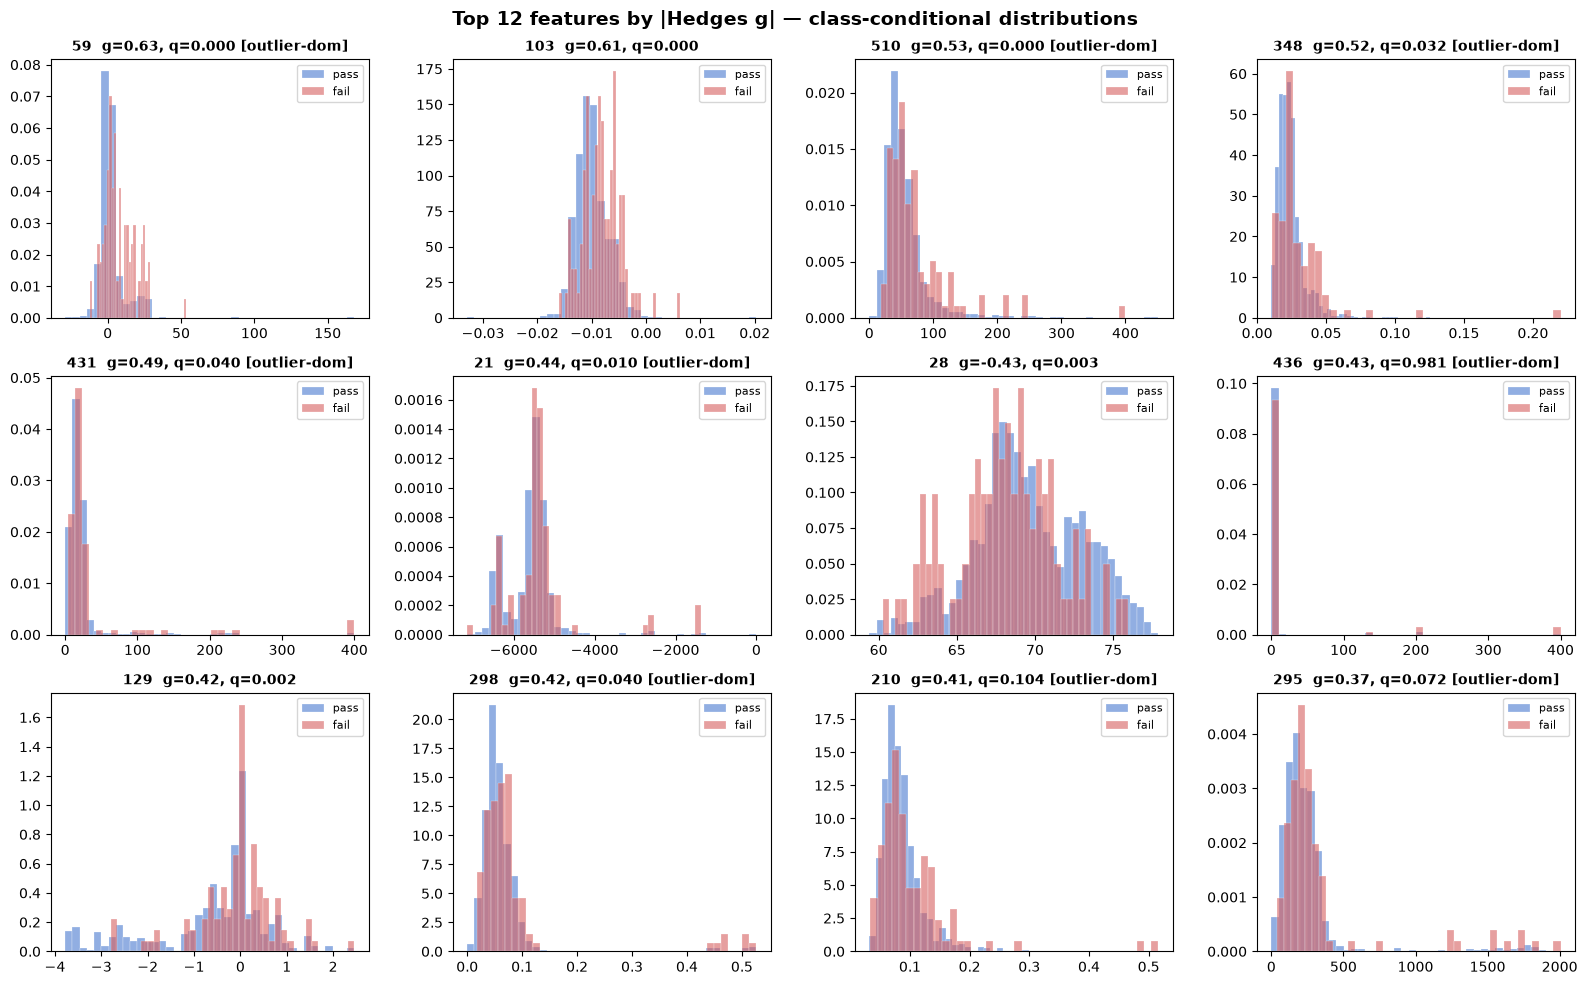

In [ ]:
# %% top-12 by |g| — class-conditional histograms
TOP_N = 12
top_feats = sep.sort_values("abs_g", ascending=False).head(TOP_N)

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for ax, (col, r) in zip(axes.flat, top_feats.iterrows(), strict=True):
    for label, color, name in [(0, "#4878CF", "pass"), (1, "#D65F5F", "fail")]:
        vals = X.loc[y_bool == label, col].dropna()
        ax.hist(
            vals,
            bins=40,
            density=True,
            alpha=0.6,
            color=color,
            edgecolor="white",
            linewidth=0.3,
            label=name,
        )

    od = bool(df_eda_diag.loc[col, "f_outlier_dom"]) if col in df_eda_diag.index else False
    flag = " [outlier-dom]" if od else ""
    ax.set_title(
        f"{col}  g={r['hedges_g']:.2f}, q={r['mw_q']:.3f}{flag}", fontsize=10, fontweight="bold"
    )
    ax.legend(fontsize=8)

fig.suptitle(
    f"Top {TOP_N} features by |Hedges g| — class-conditional distributions",
    fontsize=14,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

In [24]:
# %% tail enrichment: are extreme values enriched for fails?
TAIL_LO, TAIL_HI = 0.005, 0.995  # outermost ~1% of rows, both tails
MIN_EXTREME = 5

rows = []
for col in df_eda_diag.index[df_eda_diag["f_outlier_dom"]]:
    if col not in X.columns:
        continue
    s = X[col].dropna()
    lo, hi = s.quantile(TAIL_LO), s.quantile(TAIL_HI)
    extreme = X[col].gt(hi) | X[col].lt(lo)

    n_ext = int(extreme.sum())
    if n_ext < MIN_EXTREME:
        continue

    rows.append(
        {
            "feature": col,
            "n_extreme": n_ext,
            "fail_rate_extreme": y_bool[extreme].mean(),
            "fail_rate_rest": y_bool[~extreme].mean(),
            "tail_enrichment": y_bool[extreme].mean() / y_bool.mean(),
        }
    )

tail_check = pd.DataFrame(rows).set_index("feature").sort_values("tail_enrichment", ascending=False)
display(tail_check)

# fold back into sep so it lands in the master table
sep = sep.join(tail_check[["tail_enrichment"]])

log.info(
    f"Tail check on {len(tail_check)} outlier-dominated features: "
    f"{(tail_check['tail_enrichment'] > 2).sum()} with >2x fail enrichment"
)

,n_extreme,fail_rate_extreme,fail_rate_rest,tail_enrichment
feature,,,,
387,8,0.3750,0.064785,5.650240
426,16,0.3125,0.063830,4.708534
26,16,0.3125,0.063830,4.708534
65,16,0.2500,0.064475,3.766827
21,16,0.2500,0.064475,3.766827
...,...,...,...,...
459,16,0.0000,0.067054,0.000000
496,16,0.0000,0.067054,0.000000
491,11,0.0000,0.066838,0.000000


2026-09-01 20:13:27 | INFO    | secom | Tail check on 121 outlier-dominated features: 29 with >2x fail enrichment


**Summary:** 29 features with tail enrichment > 2× are process
excursions and their extreme tails carry the signal — do not winsorize them away for
tree models. Features with enrichment ≈ 1 are glitches; their g values are artifacts
and they drop out of the candidate list.

### 4.5 Variance shift (spread-as-signal)

Mean-shift statistics are blind to features whose *spread* changes on failing wafers
("sensor gets noisier on bad wafers"). We rank by |log2(variance ratio)| — symmetric
in up/down direction. The initial 1.5× threshold flagged 114 features (44%), which is
noise at n = 104 fails; the operative cutoff is **3× variance** (≈1.7× std), leaving
~10-15 candidates.

Caveat: variance ratios on outlier-dominated features are inflated by single extreme
rows. Cross-check f_outlier_dom (or recompute on clipped data) before believing them.

In [25]:
sep["f_var_shift"] = (sep["var_ratio"] > 1.5) | (sep["var_ratio"] < 1 / 1.5)
print(f"variance-shift candidates: {sep['f_var_shift'].sum()}")
display(sep[sep["f_var_shift"]].sort_values("var_ratio", ascending=False).head(10))

variance-shift candidates: 114


,mean_pass,mean_fail,std_pass,std_fail,var_ratio,hedges_g,mw_p,mw_q,abs_g,f_outlier_dom,f_skew_outlier_driven,missing_rate,tail_enrichment,f_var_shift
feature,,,,,,,,,,,,,,
89,0.188270,0.194647,0.043278,0.121547,7.887697,0.121711,0.026156,0.181680,0.121711,True,True,0.032546,1.883413,True
436,6.532943,21.428147,29.507059,75.042606,6.467910,0.433161,0.931240,0.980855,0.433161,True,False,0.001276,2.825120,True
337,2.303194,2.667506,1.456249,3.692121,6.428070,0.214507,0.674987,0.896891,0.214507,True,False,0.004467,1.883413,True
557,1.591206,2.075467,1.617139,3.999643,6.117129,0.259190,0.853452,0.937231,0.259190,True,True,0.165922,3.228709,True
431,21.191221,38.924103,31.835783,74.142740,5.423832,0.490434,0.002628,0.039725,0.490434,True,False,0.001276,2.825120,True
348,0.024291,0.030448,0.010346,0.024014,5.387778,0.523095,0.001602,0.031677,0.523095,True,False,0.015316,3.766827,True
437,3.986854,4.441640,1.418717,3.283832,5.357603,0.282720,0.391143,0.753174,0.282720,True,False,0.001276,1.883413,True
67,13.468253,62.207330,271.321213,623.921406,5.288010,0.158497,0.171207,0.478262,0.158497,True,False,0.003829,1.883413,True
387,0.000251,0.001580,0.004499,0.009459,4.419843,0.266692,0.176732,0.483878,0.266692,True,False,0.000000,5.650240,True


In [26]:
# %% robust variance shift (self-contained)
CLIP_LO, CLIP_HI = 0.01, 0.99

rows = []
for col in X.columns:
    s = X[col]
    lo, hi = s.quantile(CLIP_LO), s.quantile(CLIP_HI)

    p_raw, f_raw = s[~y_bool].dropna(), s[y_bool].dropna()
    p = s.clip(lo, hi)[~y_bool].dropna()
    f = s.clip(lo, hi)[y_bool].dropna()

    if len(p) < 10 or len(f) < 10 or p.var() == 0 or p_raw.var() == 0:
        continue

    iqr_p = p_raw.quantile(0.75) - p_raw.quantile(0.25)
    iqr_f = f_raw.quantile(0.75) - f_raw.quantile(0.25)

    rows.append(
        {
            "feature": col,
            "var_ratio": f_raw.var() / p_raw.var(),  # raw (recomputed here)
            "var_ratio_clip": f.var() / p.var(),  # single-row-proof
            "iqr_ratio": iqr_f / max(iqr_p, 1e-12),  # robust, on raw values
        }
    )

sep = sep.join(pd.DataFrame(rows).set_index("feature"), rsuffix="_drop")
sep = sep.drop(columns=[c for c in sep.columns if c.endswith("_drop")])  # kill duplicate var_ratio

sep["log2_vr"] = np.log2(sep["var_ratio"])
sep["log2_vr_clip"] = np.log2(sep["var_ratio_clip"])
sep["f_var_shift_strict"] = sep["log2_vr_clip"].abs() > np.log2(3)  # 3x var ≈ 1.7x std
sep["f_vr_inflated"] = (sep["log2_vr"].abs() > np.log2(3)) & (
    sep["log2_vr_clip"].abs() < np.log2(1.5)
)

log.info(
    f"Variance shift (clipped, 3x): {sep['f_var_shift_strict'].sum()} features; "
    f"{sep['f_vr_inflated'].sum()} raw ratios were outlier inflation"
)

display(
    sep[sep["f_var_shift_strict"]]
    .sort_values("log2_vr_clip", key=abs, ascending=False)[
        ["var_ratio", "var_ratio_clip", "iqr_ratio", "hedges_g", "mw_q", "f_outlier_dom"]
    ]
    .head(15)
)

2026-09-01 20:13:29 | INFO    | secom | Variance shift (clipped, 3x): 9 features; 26 raw ratios were outlier inflation


,var_ratio,var_ratio_clip,iqr_ratio,hedges_g,mw_q,f_outlier_dom
feature,,,,,,
112,0.017202,0.024539,1.115942,0.150491,0.087287,True
428,0.011686,0.027781,1.244186,-0.106366,0.071890,True
436,6.467910,4.257754,1.065876,0.433161,0.980855,True
300,3.709790,3.770995,1.139929,0.342935,0.934329,True
431,5.423832,3.605596,0.964426,0.490434,0.039725,True
26,3.913547,3.487910,0.478953,-0.329473,0.984811,True
298,3.334794,3.366030,1.220522,0.415179,0.039725,True
577,0.253924,0.304881,0.950469,-0.199410,0.469961,True
575,0.266845,0.326250,1.207888,-0.211894,0.466077,True


**Summary:** 9 features show ≥3× variance shift. Features combining a
mean shift *and* a variance shift (e.g. 348, 431) are the strongest overall
candidates — two independent distributional changes pointing the same way.

### 4.6 Mutual information (corroboration only)

MI catches what g and Mann–Whitney structurally miss: non-monotone dependence (fails
concentrated in a mid-range band while means match). Computed with median-imputed
values (MI has no NaN handling; imputation is a computational convenience for this
estimate only).

MI at n = 1567 is noisy and has no clean significance threshold, so it is used as
**corroboration, never as a selection gate**. The actionable output is the
disagreement set: high MI rank but weak g — nonlinear candidates for the tree model.

In [27]:
# %% mutual information
from scipy.stats import spearmanr
from sklearn.feature_selection import mutual_info_classif

X_mi = X.fillna(X.median())  # MI has no NaN handling; imputation is for this estimate only

mi_vals = mutual_info_classif(X_mi, y_bool, n_neighbors=5, random_state=42)
sep["mi"] = pd.Series(mi_vals, index=X_mi.columns)  # aligns by feature, not position

# mAX mi
max_mi = -0.066 * np.log(0.066) - 0.934 * np.log(0.934)
sep["mi_norm"] = sep["mi"] / max_mi
# sep is already indexed by feature; mutual_info_classif returns in X column order

sep["mi_rank"] = sep["mi"].rank(ascending=False)
sep["g_rank"] = sep["abs_g"].rank(ascending=False)

rho, _ = spearmanr(sep["mi"], sep["abs_g"])
log.info(f"MI vs |g| Spearman rho: {rho:.2f}")

sep["f_nonlinear"] = (sep["mi_rank"] <= 30) & (sep["g_rank"] > 60)

display(
    sep[sep["f_nonlinear"]][
        ["mi", "mi_norm", "mi_rank", "hedges_g", "mw_q", "var_ratio_clip"]
    ].sort_values("mi", ascending=False)
)

2026-09-01 20:13:32 | INFO    | secom | MI vs |g| Spearman rho: 0.14


,mi,mi_norm,mi_rank,hedges_g,mw_q,var_ratio_clip
feature,,,,,,
41,0.024289,0.099888,2.0,0.009887,0.753983,1.366573
570,0.021899,0.090056,4.0,-0.006646,0.795523,0.710805
416,0.020220,0.083154,5.0,-0.169011,0.343591,0.662740
2,0.019962,0.082092,6.0,-0.003826,0.645803,1.027587
571,0.017775,0.073099,8.0,-0.077675,0.731033,1.875846
428,0.017657,0.072613,9.0,-0.106366,0.071890,0.027781
132,0.016344,0.067215,12.0,0.001463,0.853413,1.267639
541,0.015814,0.065035,14.0,0.099383,0.753174,1.095330
39,0.015066,0.061956,15.0,-0.008532,0.870261,1.173319


**Summary:** MI and |g| rankings correlate at ρ ≈ 0.14. 16 features are
MI-high/g-low — the nonlinear candidates. If ρ is high (> 0.8), univariate dependence
is mostly monotone and MI added little; if low, the disagreement set deserves a look
in the top-12 plot style.

In [28]:
# %% master feature table — dedupe, then join
overlap = df_eda_diag.columns.intersection(sep.columns).tolist()
if overlap:
    log.info(f"Dropping columns duplicated by the 4.3 join: {overlap}")
    sep = sep.drop(columns=overlap)

master = df_eda_diag.join(sep, how="outer")

assert master.index.is_unique, "feature index has duplicates — investigate before saving"
# repo-rooted path; co-locate with the EDA run that produced the inputs.
# Dual format per repo convention: parquet for code, csv for humans/git.
_out = _diag.parent
master.to_parquet(_out / "eda_diagnostics_v1.parquet")
master.to_csv(_out / "eda_diagnostics_v1.csv")
log.info(f"Master feature table saved: {master.shape} -> eda_diagnostics_v1.parquet")

2026-09-01 20:13:32 | INFO    | secom | Dropping columns duplicated by the 4.3 join: ['missing_rate', 'f_outlier_dom', 'f_skew_outlier_driven']
2026-09-01 20:13:32 | INFO    | secom | Master feature table saved: (257, 46) -> eda_diagnostics_v1.parquet


### 4.7 Numeric distributions — conclusions

1. **Candidate pool established.** 23 features at |g| > 0.3, 17 passing FDR q < 0.05,
   led by features 348 and 431 (g ≈ 0.5). ~10-15 features show ≥3× variance shift.
   16 nonlinear candidates from the MI disagreement set.
2. **Outlier discipline applied.** Outlier-dominated features are marked and their
   rankings adjudicated by the tail-enrichment check rather than trusted at face
   value; feature 436 (high g, q ≈ 1) is the reference example of an outlier-driven
   mean.
3. **Shape issues documented, not treated.** Transformation watchlist (log /
   Yeo–Johnson) recorded for LR/NN models; the GBDT baseline needs none of it.
4. **Master feature table saved.** One row per feature: marginal stats, shape flags,
   missingness diagnostics, separation statistics, MI. This is the handoff artifact —
   fold-internal selection in the modeling notebook reads it rather than recomputing
   on full data.

**Next:** modeling notebook — stratified CV with fold-internal selection,
LightGBM/XGBoost with native NaN routing, with/without-indicator ablation, and a
time-blocked holdout bounded before the NaN explosion.